# Phase 0 — Replicate Grokking on Modular Addition

Goal: train a tiny 1-layer transformer on `(a + b) mod 113`, confirm the grokking phase transition (train accuracy hits 100% long before test accuracy does), and confirm the model learns the Fourier-based circuit reported in Nanda et al. (2023).

Run all cells top to bottom. On a free Colab T4 GPU this should take well under 30 minutes.

In [9]:
!pip install -q "transformer_lens<3" einops

In [10]:
!pip install "transformer_lens<3" --no-cache-dir -q

In [11]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [12]:
!pip uninstall -y transformer_lens -q

## 1. Data generation
Sequence format: `[a, op_token, b, equals_token] -> result`. Only one op (`add`) for this phase.

In [13]:
def make_dataset(p=113, ops=("add",), train_frac=0.3, seed=0):
    OPS = {
        "add": lambda a, b, p: (a + b) % p,
        "sub": lambda a, b, p: (a - b) % p,
        "mul": lambda a, b, p: (a * b) % p,
    }
    rng = np.random.RandomState(seed)
    op_list = list(ops)
    equals_token = p + len(op_list)

    all_inputs, all_labels = [], []
    for op_idx, op_name in enumerate(op_list):
        op_token = p + op_idx
        fn = OPS[op_name]
        for a in range(p):
            for b in range(p):
                all_inputs.append([a, op_token, b, equals_token])
                all_labels.append(fn(a, b, p))

    inputs = torch.tensor(all_inputs, dtype=torch.long)
    labels = torch.tensor(all_labels, dtype=torch.long)

    n = len(inputs)
    perm = rng.permutation(n)
    n_train = int(train_frac * n)
    train_idx, test_idx = perm[:n_train], perm[n_train:]

    vocab_size = p + len(op_list) + 1
    return (inputs[train_idx], labels[train_idx]), (inputs[test_idx], labels[test_idx]), vocab_size, equals_token, op_list

p = 113
train_data, test_data, vocab_size, equals_token, op_list = make_dataset(p=p, ops=("add",), train_frac=0.3)
print("vocab size:", vocab_size, "train examples:", train_data[0].shape[0], "test examples:", test_data[0].shape[0])

vocab size: 115 train examples: 3830 test examples: 8939


## 2. Model — tiny 1-layer transformer

In [14]:
cfg = HookedTransformerConfig(
    n_layers=1,
    d_model=128,
    d_head=32,
    n_heads=4,
    d_mlp=512,
    d_vocab=vocab_size,
    n_ctx=4,
    act_fn="relu",
    normalization_type=None,
    seed=0,
    device=device,
)
model = HookedTransformer(cfg)
print(model)

HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0): TransformerBlock(
      (ln1): Identity()
      (ln2): Identity()
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (hook_resid_pre): HookPoint()
      (hook_resid_mid): HookPoint()
      (hook_resid_post): HookPoint()
    )
  )
  (unembed): Unembed()
)


## 3. Training loop
Weight decay is the key knob for grokking to actually occur -- if you don't see the phase transition, try sweeping `weight_decay` (e.g. 0.1, 0.5, 1.0, 2.0) before assuming something else is wrong.

In [15]:
train_inputs, train_labels = train_data[0].to(device), train_data[1].to(device)
test_inputs, test_labels = test_data[0].to(device), test_data[1].to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98))

epochs = 15000
checkpoint_every = 200
history = {"epoch": [], "train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
checkpoints = []

for epoch in tqdm(range(epochs)):
    model.train()
    logits = model(train_inputs)[:, -1, :]
    loss = F.cross_entropy(logits, train_labels)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if epoch % checkpoint_every == 0 or epoch == epochs - 1:
        model.eval()
        with torch.no_grad():
            tr_logits = model(train_inputs)[:, -1, :]
            te_logits = model(test_inputs)[:, -1, :]
            tr_loss = F.cross_entropy(tr_logits, train_labels).item()
            te_loss = F.cross_entropy(te_logits, test_labels).item()
            tr_acc = (tr_logits.argmax(-1) == train_labels).float().mean().item()
            te_acc = (te_logits.argmax(-1) == test_labels).float().mean().item()
        history["epoch"].append(epoch)
        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        checkpoints.append({k: v.detach().cpu().clone() for k, v in model.state_dict().items()})

100%|██████████| 15000/15000 [03:35<00:00, 69.68it/s]


## 4. Plot loss/accuracy curves — look for the grokking phase transition

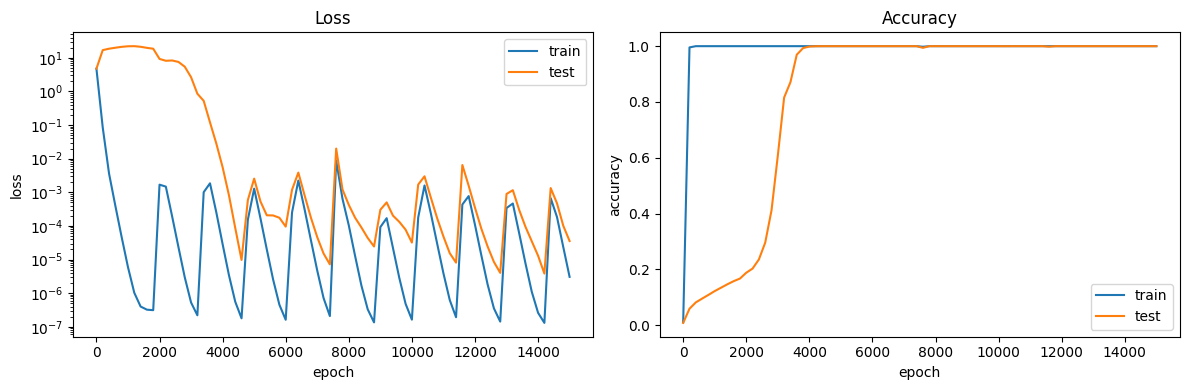

Saved loss_curves.png -- commit this to your repo's results/ folder as evidence of progress.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["test_loss"], label="test")
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].set_title("Loss")

axes[1].plot(history["epoch"], history["train_acc"], label="train")
axes[1].plot(history["epoch"], history["test_acc"], label="test")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend(); axes[1].set_title("Accuracy")
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()
print("Saved loss_curves.png -- commit this to your repo's results/ folder as evidence of progress.")

## 5. Fourier analysis of the embedding — read off the circuit
If the model has grokked and learned the known Fourier-based circuit, a small number of frequencies should dominate the power spectrum below.

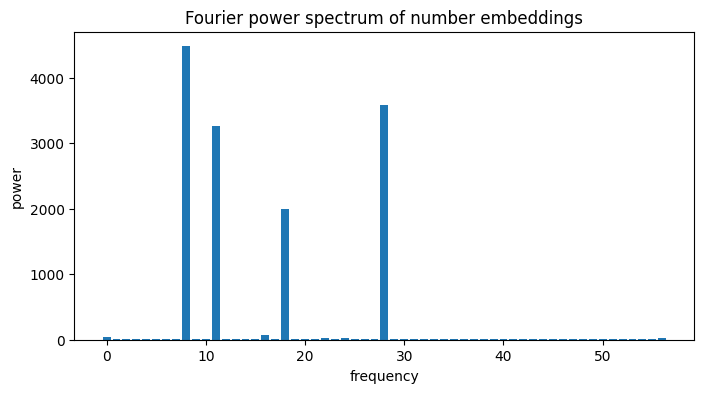

Saved fourier_spectrum.png -- a handful of tall spikes = the model learned a sparse Fourier circuit.


In [17]:
W_E = model.W_E[:p].detach().cpu().numpy()
fourier_basis = np.fft.rfft(W_E, axis=0)
power = np.abs(fourier_basis) ** 2
power_per_freq = power.sum(axis=1)

plt.figure(figsize=(8, 4))
plt.bar(range(len(power_per_freq)), power_per_freq)
plt.xlabel("frequency"); plt.ylabel("power"); plt.title("Fourier power spectrum of number embeddings")
plt.savefig("fourier_spectrum.png", dpi=150)
plt.show()
print("Saved fourier_spectrum.png -- a handful of tall spikes = the model learned a sparse Fourier circuit.")